In [1]:
import logging
import os
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle
from openretina.models.core_readout import load_core_readout_from_remote
from openretina.utils.file_utils import get_cache_directory, get_local_file_path, optionally_download_from_url
from openretina.utils.misc import CustomPrettyPrinter

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)  # to display logs in jupyter notebooks

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pp = CustomPrettyPrinter(indent=4, max_lines=40)

In [2]:
movie_stimulus_path = get_local_file_path(
    "https://huggingface.co/datasets/open-retina/open-retina/blob/main/euler_lab/hoefling_2024/stimuli/rgc_natstim_72x64_joint_normalized_2024-10-11.zip"
)

movie_stimuli = movies_from_pickle(movie_stimulus_path)

2025-12-23 17:15:07,539 - INFO - Fetching file list for open-retina/open-retina...
2025-12-23 17:15:08,161 - INFO - Found target file at /home/bethge/bkr618/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_72x64_joint_normalized_2024-10-11.pkl


# Loading a model

Now we are going to load a retina model that was trained on neural responses to this data. This is as easy as running:

In [3]:
import hydra
with hydra.initialize(config_path=os.path.join("..", "configs"), version_base="1.3"):
    cfg = hydra.compose(config_name="hoefling_2024_core_readout_low_res.yaml")

In [4]:
responses_path = "/home/bethge/bkr618/openretina_cache/data/euler_lab/hoefling_2024/responses/rgc_natstim_2024-08-14.h5"
from openretina.utils.h5_handling import load_h5_into_dict
from openretina.data_io.hoefling_2024.responses import filter_responses, make_final_responses
from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle
responses_dict = load_h5_into_dict(file_path=responses_path)

filtered_responses_dict = filter_responses(responses_dict, **cfg.quality_checks)

final_responses = make_final_responses(filtered_responses_dict, response_type="natural")

Loading HDF5 file contents:   0%|          | 0/2077 [00:00<?, ?item/s]

Original dataset contains 7863 neurons over 67 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (67 remaining)
Overall, dropped 3034 neurons of non-target cell types (-38.59%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (67 remaining)
Overall, dropped 980 neurons over quality checks (-20.29%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 705 neurons with classifier confidences below 0.25 (-18.32%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 3144 neurons over 67 fields
Total number of cells dropped: 4719 (-60.02%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/67 [00:00<?, ?it/s]

In [5]:
from openretina.data_io.base import compute_data_info
data_info = compute_data_info(neuron_data_dictionary=final_responses, movies_dictionary=movie_stimuli)
n_neurons_dict = data_info["n_neurons_dict"]

In [6]:
#downsampled
#file_path = "/mnt/lustre/work/bethge/bkr618/hyperparams_search/openretina_assets/runs/transformer_temporal_hyperparams_search/2025-12-02_18-15-32/1/checkpoints/epoch=32_val_correlation=0.183_final.ckpt"
#file_path = "/home/bethge/bkr618/openretina_cache/notebook_example/tensorboard/version_63/checkpoints/epoch=27-step=3752.ckpt"
file_path ="/mnt/lustre/work/bethge/bkr618/hyperparams_search/openretina_assets/runs/high_reg/2025-12-08_10-28-36/checkpoints/epoch=24_val_correlation=0.209.ckpt"
from openretina.models.core_readout import UnifiedCoreReadout

model = UnifiedCoreReadout.load_from_checkpoint(file_path, map_location="cuda", n_neurons_dict = n_neurons_dict)

In [7]:
from openretina.data_io.cyclers import LongCycler, ShortCycler

In [8]:
from openretina.data_io.hoefling_2024.dataloaders import natmov_dataloaders_v2

In [9]:
dataloaders = natmov_dataloaders_v2(
    neuron_data_dictionary=final_responses,
    movies_dictionary=movie_stimuli,
    allow_over_boundaries=True,
    batch_size=64,
    train_chunk_size=50,
    validation_clip_indices=cfg.dataloader.validation_clip_indices,
)

Creating movie dataloaders:   0%|          | 0/67 [00:00<?, ?it/s]

In [10]:
train_loader = LongCycler(dataloaders["train"])
val_loader = ShortCycler(dataloaders["validation"])

In [10]:
test_loader = ShortCycler(dataloaders["test"])

In [12]:
import lightning

In [76]:
trainer =  lightning.Trainer(max_epochs=100, precision = '16-mixed') #add precision

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [97]:
trainer.test(model, dataloaders=[train_loader, val_loader, test_loader])

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_correlation      │    0.17443394660949707    │    0.20949095487594604    │    0.40702736377716064    │
│         test_loss         │     269.2373352050781     │     356.5923156738281     │    36.216583251953125     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

[{'test_loss/dataloader_idx_0': 269.2373352050781,
  'test_correlation/dataloader_idx_0': 0.17443394660949707},
 {'test_loss/dataloader_idx_1': 356.5923156738281,
  'test_correlation/dataloader_idx_1': 0.20949095487594604},
 {'test_loss/dataloader_idx_2': 36.216583251953125,
  'test_correlation/dataloader_idx_2': 0.40702736377716064}]

# Visualizing model predictions

In [98]:
# First, put the stimuli in a torch tensor, which is what the model expects.
stim = torch.Tensor(movie_stimuli.test_movie).to(model.device)

# Second, we need to select one of the many experimental sessions the model was trained on to visualize a response.
example_session = "session_5_ventral2_20210910"
#model.readout.sessions[0]  # Can pick any number as long as it is in range

with torch.no_grad():
    #predicted_response = model.forward(stim.unsqueeze(0), data_key=example_session)
    predicted_response = model.forward(stim.unsqueeze(0), data_key=example_session)
predicted_response_numpy = predicted_response.squeeze().cpu().numpy()

In [99]:
# Create a dropdown for neuron selection
neuron_selector = widgets.Dropdown(
    options=list(range(predicted_response_numpy.shape[1])),
    value=0,
    description="Neuron:",
)


# Define the plotting function
def plot_response(neuron_idx):
    plt.figure(figsize=(12, 6))
    plt.plot(predicted_response_numpy[:, neuron_idx])
    plt.xlabel("Time [frames]")
    plt.ylabel("Response [a.u.]")
    sns.despine()
    plt.show()


# Create an interactive widget
widgets.interactive(plot_response, neuron_idx=neuron_selector)

interactive(children=(Dropdown(description='Neuron:', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…

In [12]:
import torch
import numpy as np
from scipy.stats import pearsonr
from tqdm import tqdm

# select up to 10 sessions
num_sessions = len(model.readout.sessions)
predictions = {}
accuracies = {}
best_neuron_per_session = {}

stim = torch.Tensor(movie_stimuli.test_movie).to(model.device)
# Step 1: predict responses per session
for sess_idx in tqdm(range(num_sessions)):
    session_key = model.readout.sessions[sess_idx]
    with torch.no_grad():
        pred = model.forward(stim.unsqueeze(0), data_key=session_key)
        pred = pred.squeeze().cpu().numpy()  # shape [time, neurons]
    predictions[session_key] = pred

100%|██████████| 67/67 [00:03<00:00, 17.50it/s]


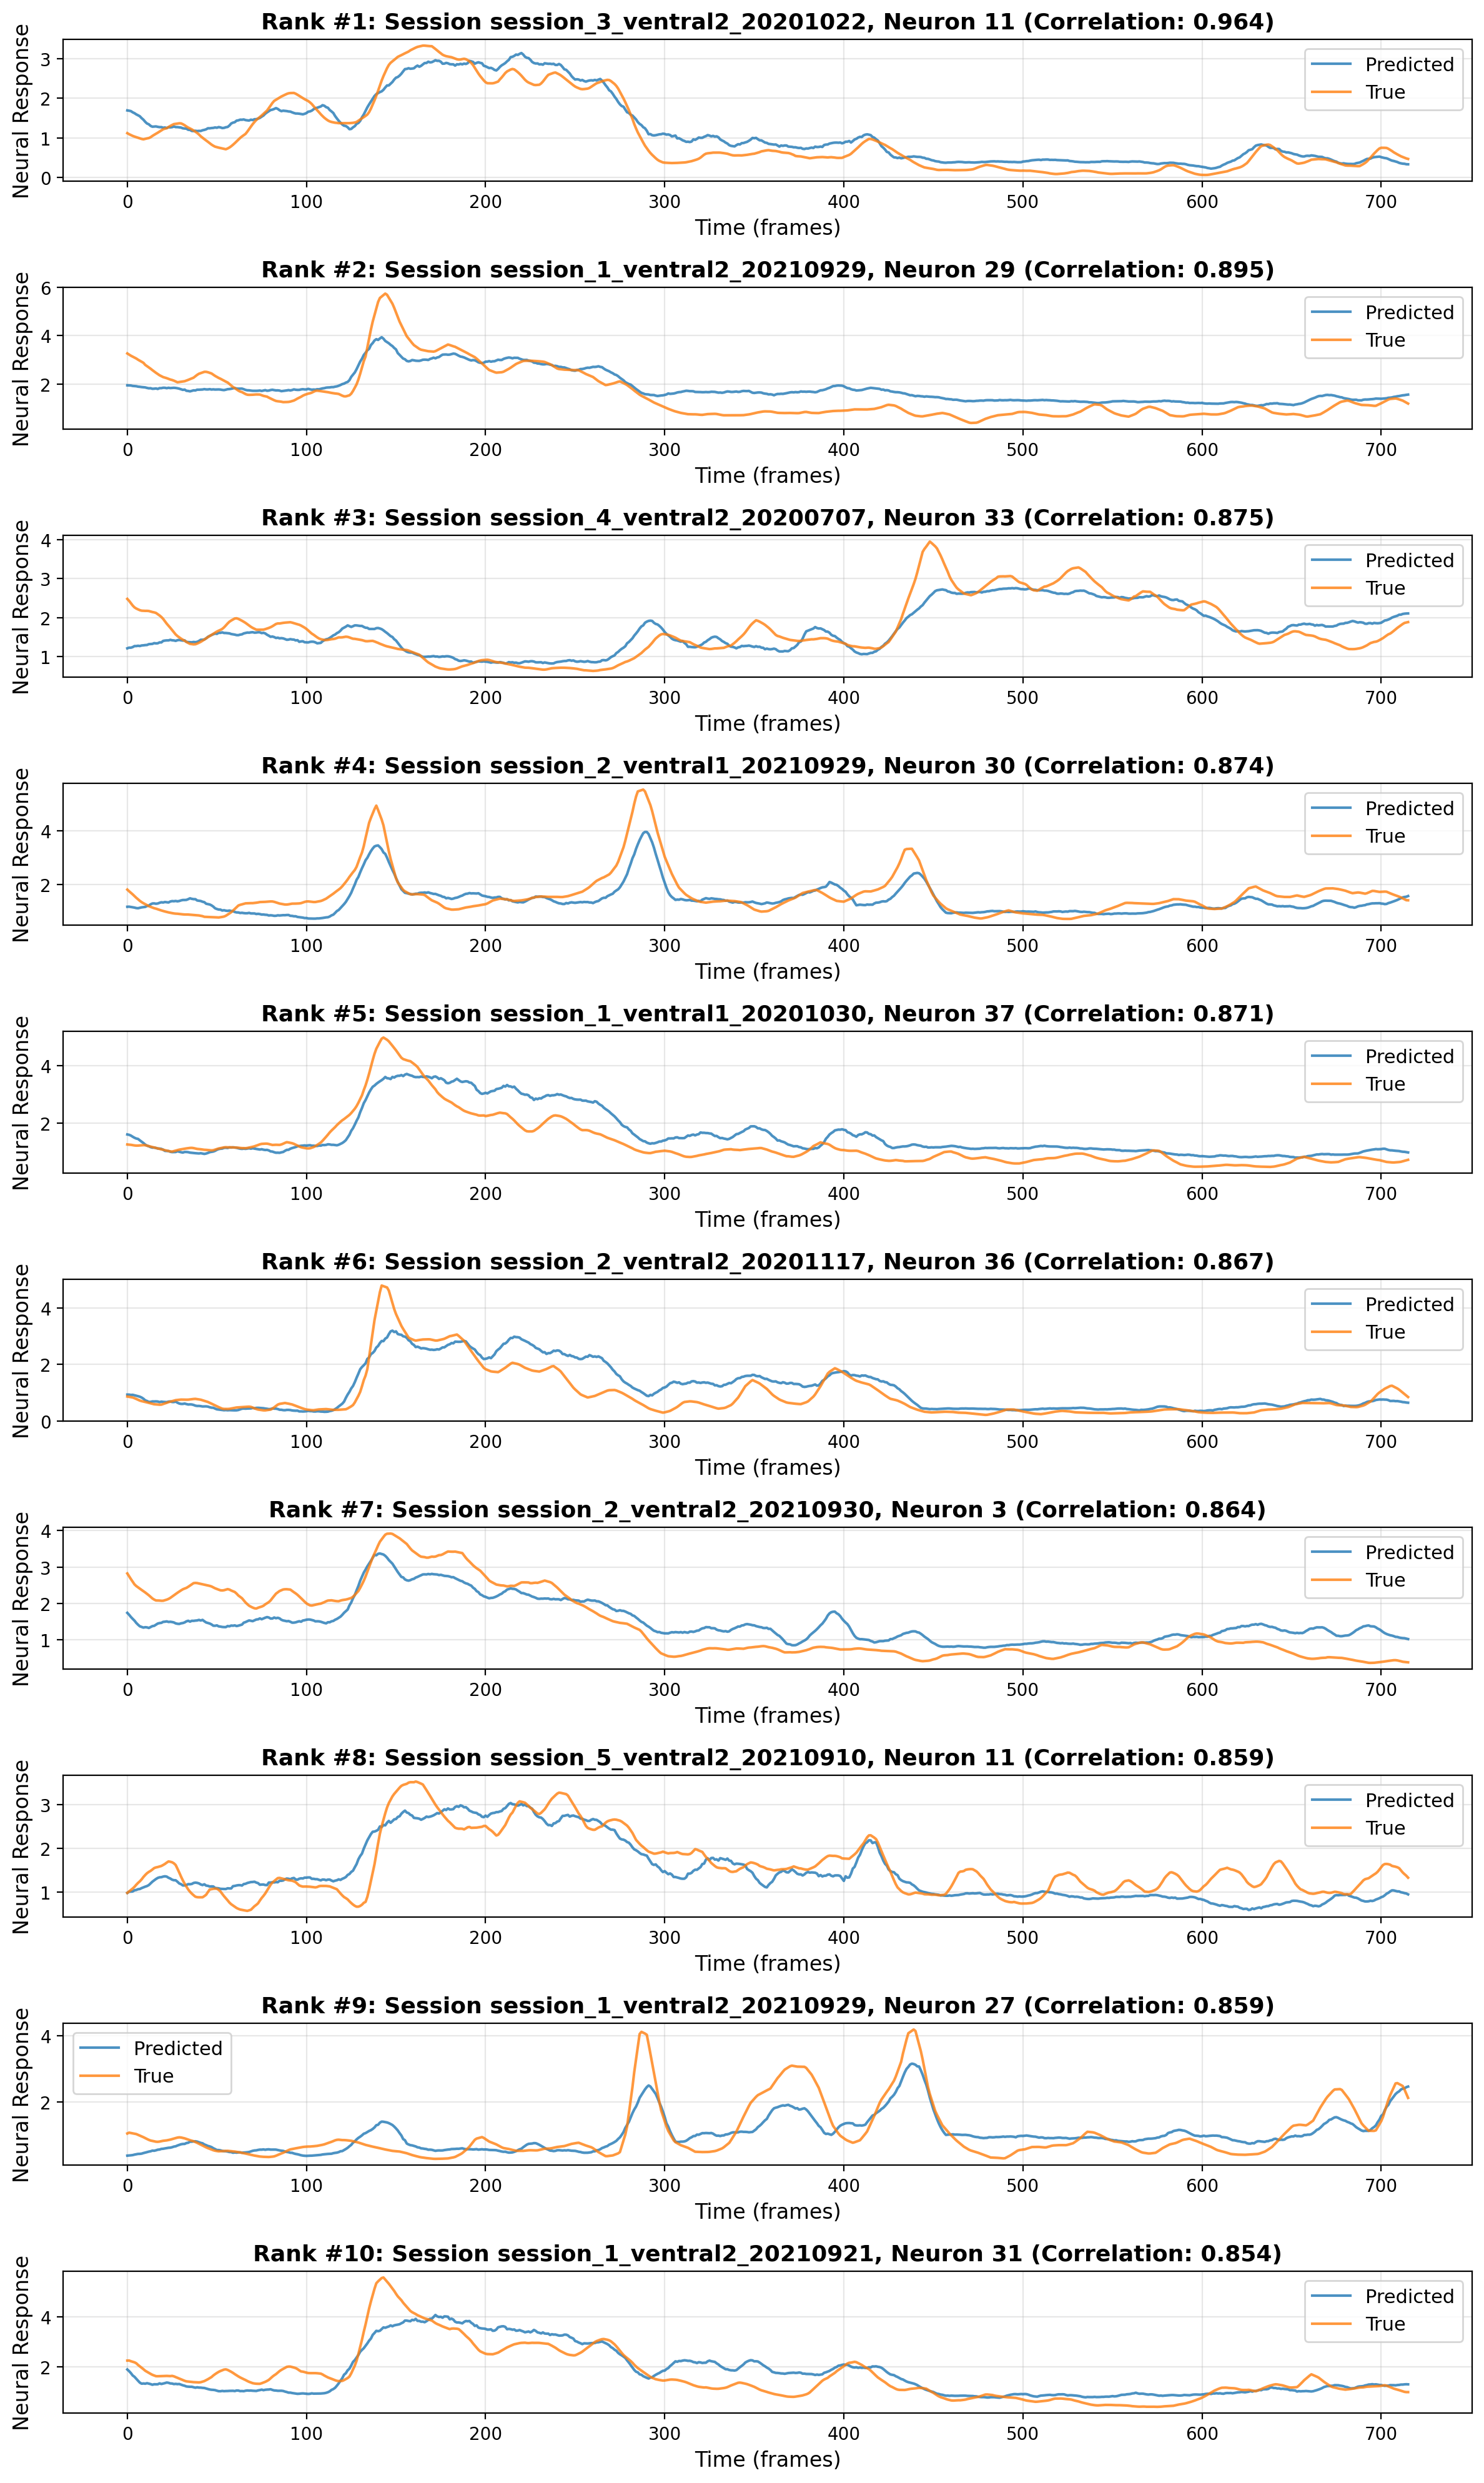

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from openretina.modules.losses import CorrelationLoss3d
accuracies = {}
best_neuron_per_session = {}
all_neurons_performance = []  # Store (session, neuron_idx, correlation) for all neurons

# Step 2: compute per-neuron accuracy using test_loader
for item in test_loader:
    sess = item[0]  # session key
    if sess in predictions.keys():
        pred = predictions[sess]  # predicted response for this session
        true = item[1].targets  # true response from test_loader (torch tensor)
        
        # Sample true responses at patch centers to match predictions
        with torch.no_grad():
            sampled_true = model._sample_targets_at_patch_centers(
                true, 
                item[1].inputs.size(2)
            ).squeeze(0).cpu().numpy()
        
        # Ensure pred and true match in length
  
        pred_trunc = pred
        true_trunc = sampled_true
        
        # Convert to torch tensors and add batch dimension
        pred_tensor = torch.tensor(pred_trunc, dtype=torch.float32).unsqueeze(0)  # [1, time, neurons]
        true_tensor = torch.tensor(true_trunc, dtype=torch.float32).unsqueeze(0)  # [1, time, neurons]
        
        # Compute per-neuron correlations
        correlation_loss_per_neuron = CorrelationLoss3d(avg=False)
        
        with torch.no_grad():
            corr_loss = correlation_loss_per_neuron(pred_tensor, true_tensor)
            
            # Negate (since it's a loss) and convert to numpy
            if corr_loss.dim() == 0:  # scalar
                # If still scalar, compute per neuron manually
                N = pred_tensor.shape[2]
                acc = np.zeros(N)
                for i in range(N):
                    loss_i = correlation_loss_per_neuron(pred_tensor[:, :, i:i+1], true_tensor[:, :, i:i+1])
                    acc[i] = -loss_i.item()
            else:
                acc = -corr_loss.squeeze().numpy()  # should be [neurons]
        
        accuracies[sess] = acc
        
        # Store all neuron performances
        for neuron_idx, corr_val in enumerate(acc):
            all_neurons_performance.append((sess, neuron_idx, corr_val, pred_trunc, true_trunc))
        
        # Find best neuron for this session
        best_idx = np.argmax(acc)
        best_neuron_per_session[sess] = (best_idx, acc[best_idx])


# Find top 2 performing neurons across ALL sessions
all_neurons_performance.sort(key=lambda x: x[2], reverse=True)
top_2_neurons = all_neurons_performance[:10]

# Plot side-by-side comparison for top 2 neurons
fig, axes = plt.subplots(10, 1, figsize=(12, 20))

for idx, (sess, neuron_idx, corr_val, pred_data, true_data) in enumerate(top_2_neurons):
    ax = axes[idx]
    
    time_points = np.arange(pred_data.shape[0])
    
    ax.plot(time_points, pred_data[:, neuron_idx], label='Predicted', linewidth=1.5, alpha=0.8)
    ax.plot(time_points, true_data[:, neuron_idx], label='True', linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('Time (frames)', fontsize=12)
    ax.set_ylabel('Neural Response', fontsize=12)
    ax.set_title(f'Rank #{idx+1}: Session {sess}, Neuron {neuron_idx} (Correlation: {corr_val:.3f})', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


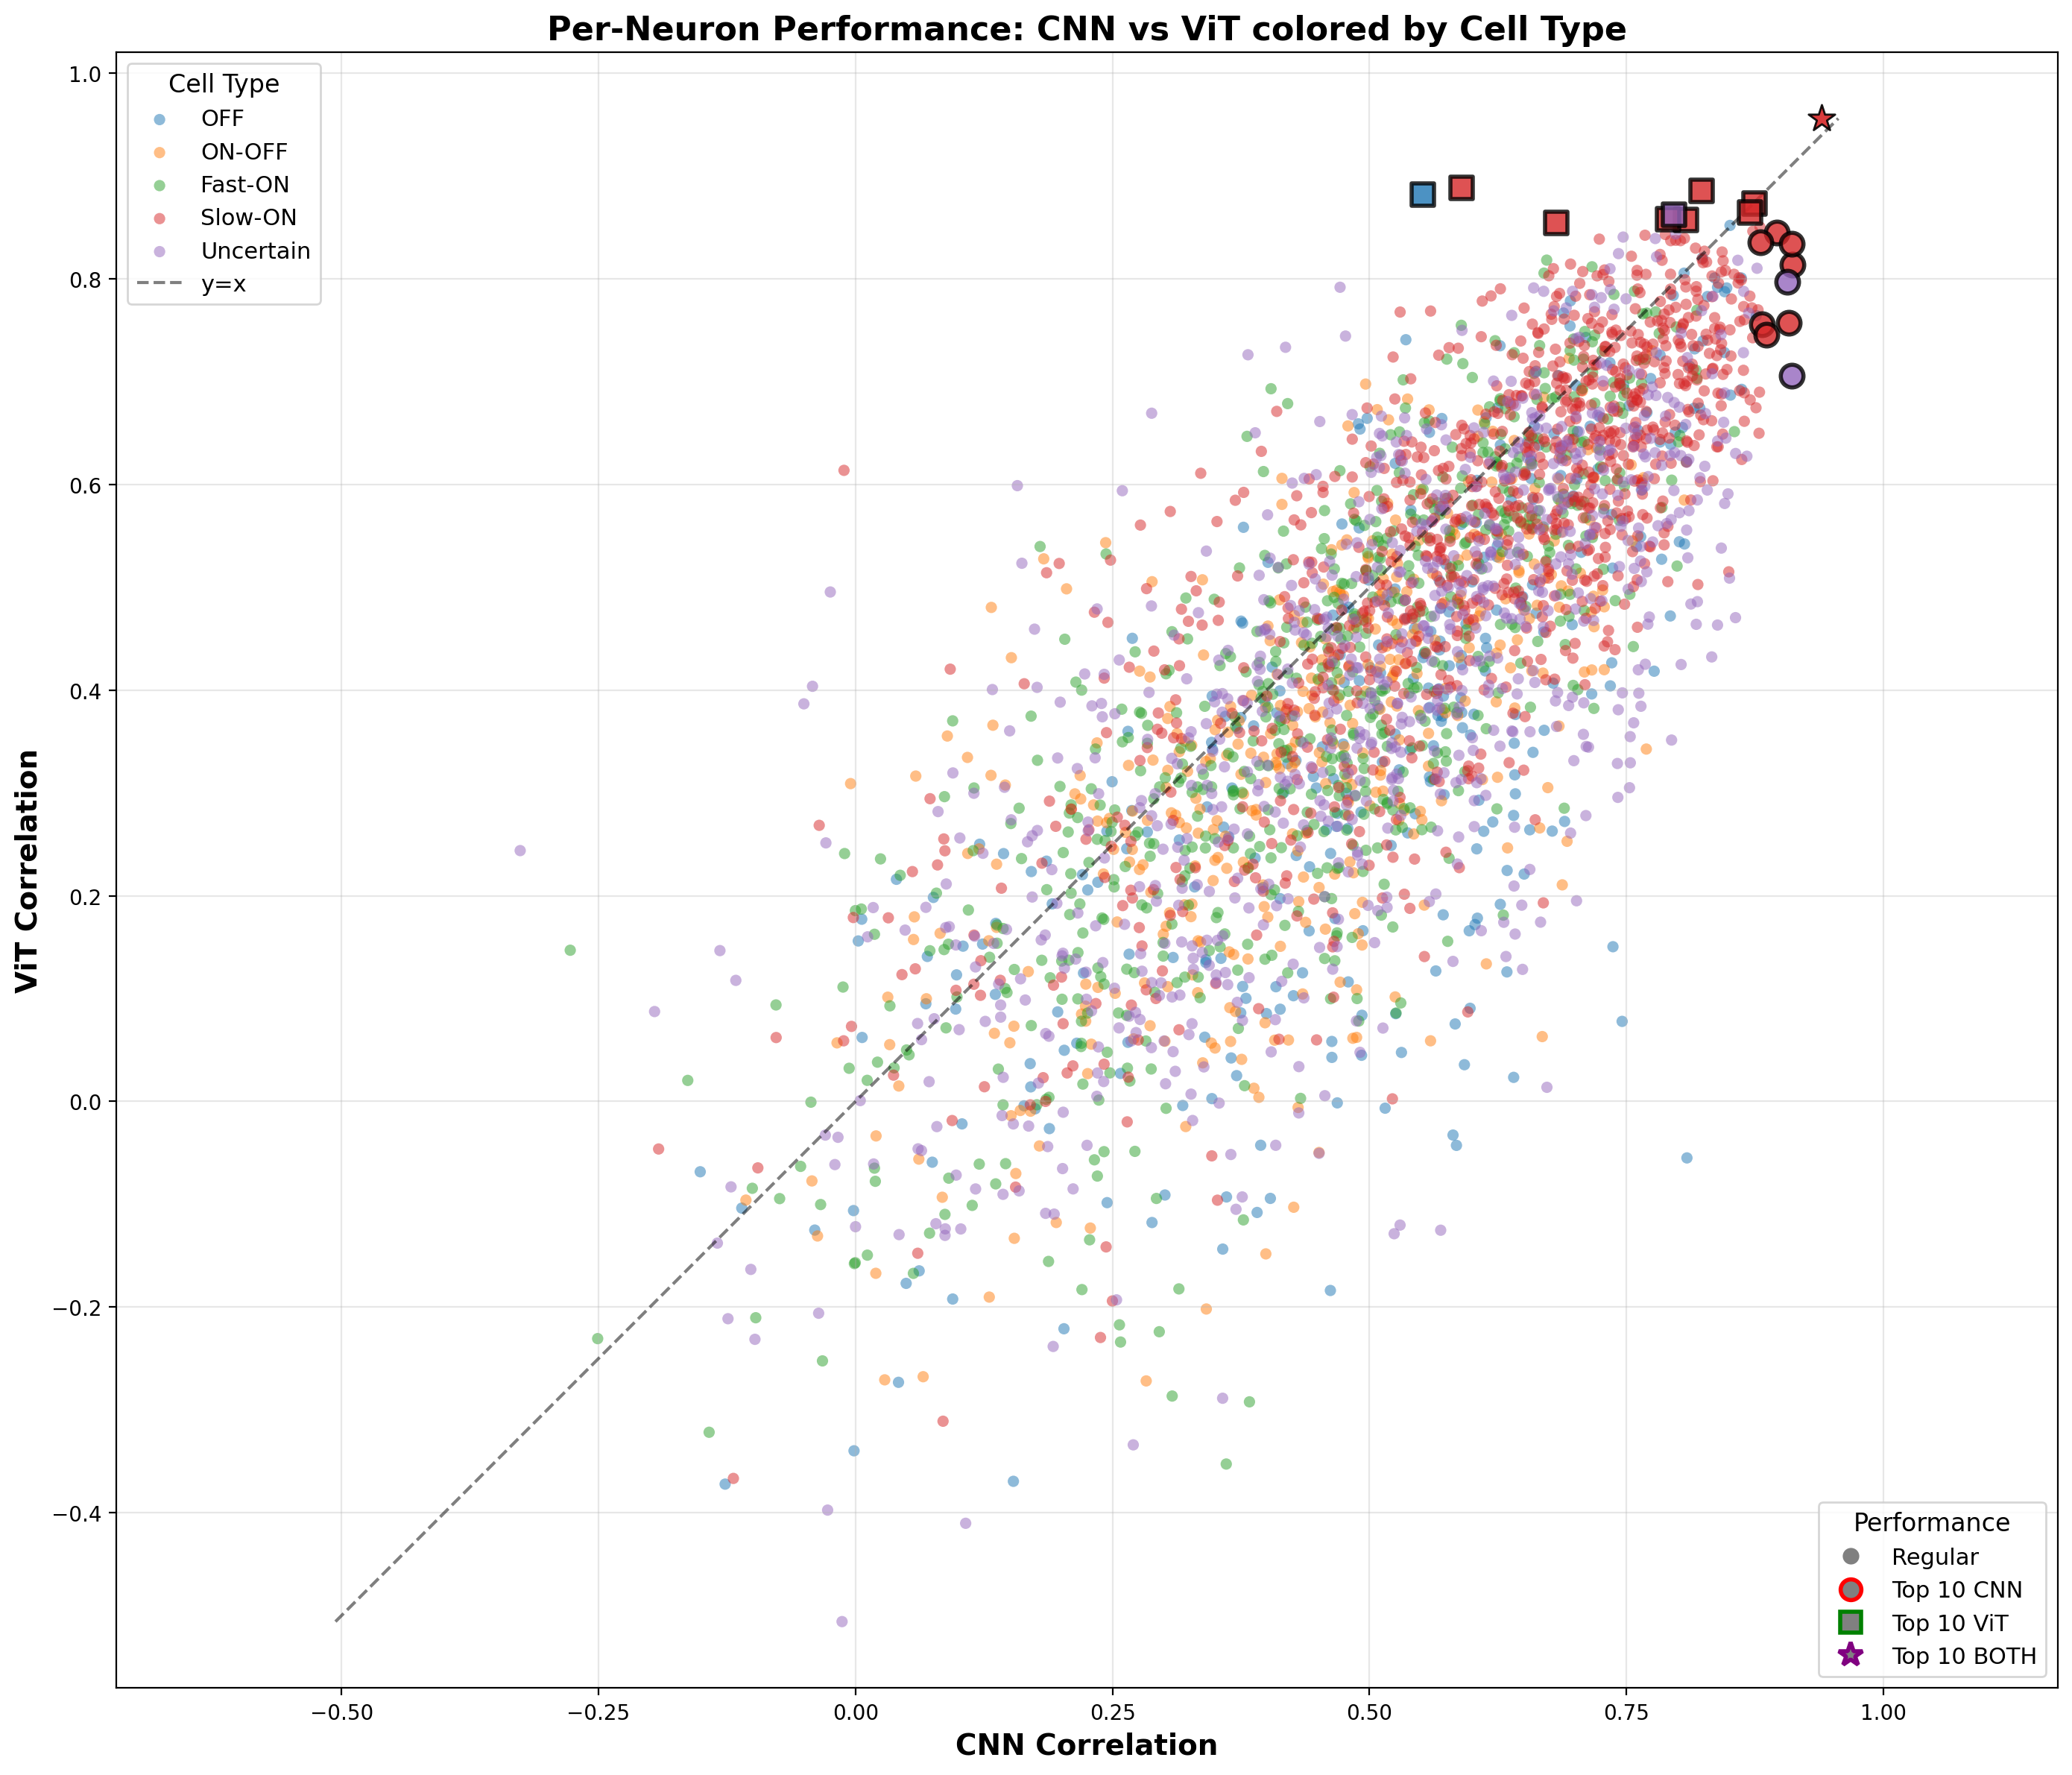

Number of matched neurons: 3144

Breakdown by cell type:

OFF: 320 neurons
  CNN: 0.500 ± 0.216
  ViT: 0.345 ± 0.257

ON-OFF: 412 neurons
  CNN: 0.434 ± 0.177
  ViT: 0.331 ± 0.195

Fast-ON: 667 neurons
  CNN: 0.447 ± 0.202
  ViT: 0.371 ± 0.226

Slow-ON: 956 neurons
  CNN: 0.602 ± 0.192
  ViT: 0.541 ± 0.201

Uncertain: 789 neurons
  CNN: 0.495 ± 0.222
  ViT: 0.388 ± 0.233


In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists to dictionaries for easy lookup
cnn_dict = {(sess, neuron_idx): corr for sess, neuron_idx, corr, _, _ in all_neurons_performance_cnn}
vit_dict = {(sess, neuron_idx): corr for sess, neuron_idx, corr, _, _ in all_neurons_performance}

# Find common neurons
common_keys = set(cnn_dict.keys()) & set(vit_dict.keys())

# Extract matched correlations
cnn_corrs = [cnn_dict[key] for key in common_keys]
vit_corrs = [vit_dict[key] for key in common_keys]

# Get top 10 neurons for each model
top10_cnn = set([key for key, _ in sorted(cnn_dict.items(), key=lambda x: x[1], reverse=True)[:10]])
top10_vit = set([key for key, _ in sorted(vit_dict.items(), key=lambda x: x[1], reverse=True)[:10]])

# Find neurons in top 10 for both models
top10_both = top10_cnn & top10_vit & common_keys
top10_cnn_only = (top10_cnn & common_keys) - top10_both
top10_vit_only = (top10_vit & common_keys) - top10_both

def remap(g):
    if 0 <= g <= 8:
        return "OFF"
    if 9 <= g <= 13:
        return "ON-OFF"
    if 14 <= g <= 19:
        return "Fast-ON"
    if 20 <= g <= 27:
        return "Slow-ON"
    if 28 <= g <= 32:
        return "Uncertain"
    return "Unknown"

# Get group assignments for all common neurons
neuron_groups = {}
for sess, neuron_idx in common_keys:
    group_assignment = data_info["sessions_kwargs"][sess]["group_assignment"]
    original_group = group_assignment[neuron_idx]
    macro_group = remap(original_group)
    neuron_groups[(sess, neuron_idx)] = macro_group

# Define colors for each macro group
group_colors = {
    "OFF": "#1f77b4",        # blue
    "ON-OFF": "#ff7f0e",     # orange
    "Fast-ON": "#2ca02c",    # green
    "Slow-ON": "#d62728",    # red
    "Uncertain": "#9467bd",  # purple
    "Unknown": "#7f7f7f"     # gray
}

# Organize neurons by group and top-10 status
group_data = {group: {'regular': [], 'cnn_top10': [], 'vit_top10': [], 'both_top10': []} 
              for group in group_colors.keys()}

for key in common_keys:
    group = neuron_groups[key]
    cnn_val = cnn_dict[key]
    vit_val = vit_dict[key]
    
    if key in top10_both:
        group_data[group]['both_top10'].append((cnn_val, vit_val))
    elif key in top10_cnn_only:
        group_data[group]['cnn_top10'].append((cnn_val, vit_val))
    elif key in top10_vit_only:
        group_data[group]['vit_top10'].append((cnn_val, vit_val))
    else:
        group_data[group]['regular'].append((cnn_val, vit_val))

# Create scatter plot
plt.figure(figsize=(14, 12))

# Plot each group
for group, color in group_colors.items():
    data = group_data[group]
    
    # Regular neurons (no edge, smaller)
    if data['regular']:
        reg_cnn, reg_vit = zip(*data['regular'])
        plt.scatter(reg_cnn, reg_vit, alpha=0.5, s=30, c=color, 
                    edgecolors='none', label=f'{group}', zorder=1)
    
    # CNN top 10 only (red edge, circles)
    if data['cnn_top10']:
        cnn_cnn, cnn_vit = zip(*data['cnn_top10'])
        plt.scatter(cnn_cnn, cnn_vit, alpha=0.8, s=120, c=color, 
                    edgecolors='black', linewidths=2, marker='o', zorder=3)
    
    # ViT top 10 only (green edge, squares)
    if data['vit_top10']:
        vit_cnn, vit_vit = zip(*data['vit_top10'])
        plt.scatter(vit_cnn, vit_vit, alpha=0.8, s=120, c=color, 
                    edgecolors='black', linewidths=2, marker='s', zorder=3)
    
    # Both top 10 (purple edge, stars)
    if data['both_top10']:
        both_cnn, both_vit = zip(*data['both_top10'])
        plt.scatter(both_cnn, both_vit, alpha=0.9, s=180, c=color, 
                    edgecolors='black', linewidths=1, marker='*', zorder=4)

# Add diagonal line
min_val = min(min(cnn_corrs), min(vit_corrs))
max_val = max(max(cnn_corrs), max(vit_corrs))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, 
         alpha=0.5, label='y=x', zorder=2)

# Create custom legend for edge types
from matplotlib.lines import Line2D
edge_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
           markeredgecolor='none', markersize=8, label='Regular'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
           markeredgecolor='red', markersize=10, markeredgewidth=2, label='Top 10 CNN'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
           markeredgecolor='green', markersize=10, markeredgewidth=2, label='Top 10 ViT'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', 
           markeredgecolor='purple', markersize=12, markeredgewidth=2, label='Top 10 BOTH')
]

plt.xlabel('CNN Correlation', fontsize=14, fontweight='bold')
plt.ylabel('ViT Correlation', fontsize=14, fontweight='bold')
plt.title(f'Per-Neuron Performance: CNN vs ViT colored by Cell Type', 
          fontsize=16, fontweight='bold')

# Add two legends: one for groups, one for edge types
leg1 = plt.legend(loc='upper left', fontsize=11, title='Cell Type', title_fontsize=12)
plt.gca().add_artist(leg1)
plt.legend(handles=edge_legend, loc='lower right', fontsize=11, title='Performance', title_fontsize=12)

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Print statistics by group
print(f"Number of matched neurons: {len(common_keys)}")
print(f"\nBreakdown by cell type:")
for group in group_colors.keys():
    group_neurons = [k for k, v in neuron_groups.items() if v == group]
    if group_neurons:
        group_cnn = [cnn_dict[k] for k in group_neurons]
        group_vit = [vit_dict[k] for k in group_neurons]
        print(f"\n{group}: {len(group_neurons)} neurons")
        print(f"  CNN: {np.mean(group_cnn):.3f} ± {np.std(group_cnn):.3f}")
        print(f"  ViT: {np.mean(group_vit):.3f} ± {np.std(group_vit):.3f}")

/tmp/ipykernel_3638768/1658301457.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True)


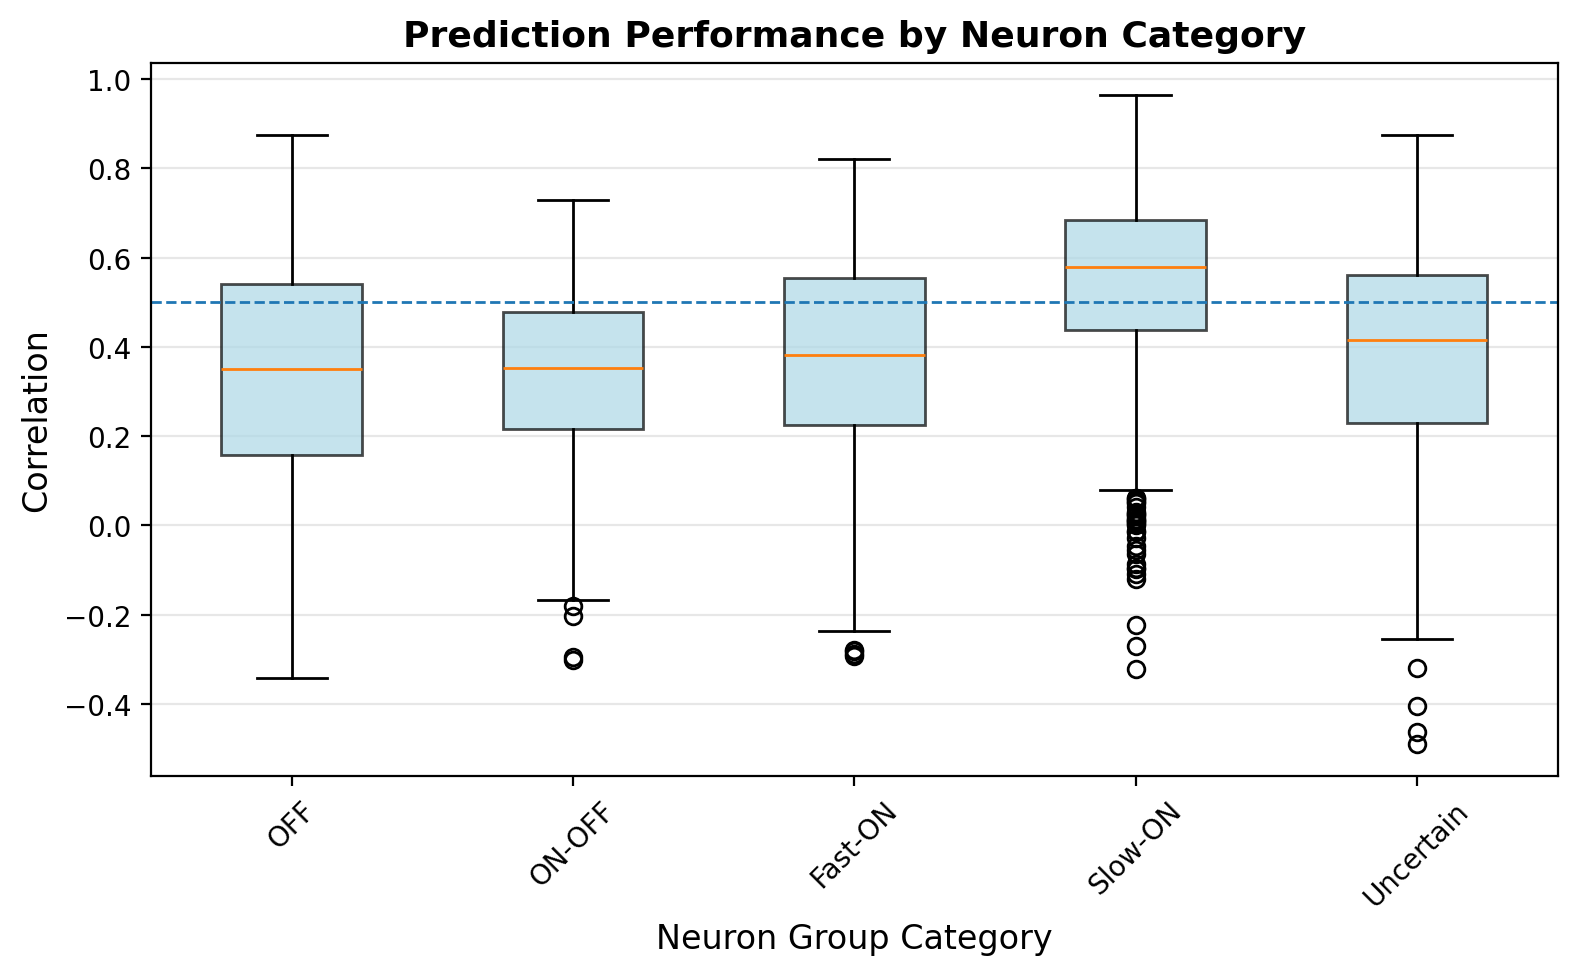


Summary

Best performing category: Slow-ON (mean corr = 0.5394, N = 956 neurons)
Worst performing category: ON-OFF (mean corr = 0.3339, N = 412 neurons)

Full ranking (best to worst):
  1. Slow-ON     : 0.5394 (N=956)
  2. Uncertain   : 0.3860 (N=789)
  3. Fast-ON     : 0.3704 (N=667)
  4. OFF         : 0.3469 (N=320)
  5. ON-OFF      : 0.3339 (N=412)


In [17]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy import stats
import torch

# Define remapping function
def remap(g):
    if 0 <= g <= 8:
        return "OFF"
    if 9 <= g <= 13:
        return "ON-OFF"
    if 14 <= g <= 19:
        return "Fast-ON"
    if 20 <= g <= 27:
        return "Slow-ON"
    if 28 <= g <= 32:
        return "Uncertain"
    return "Unknown"

# Step 1: Collect correlations grouped by remapped neuron group across all sessions
group_correlations = defaultdict(list)  # key: remapped group name, value: list of correlations

for item in test_loader:
    sess = item[0]  # session key
    if sess in predictions.keys():
        pred = predictions[sess]
        
        # Get true response and sample at patch centers
        true = item[1].targets  # torch tensor
        
        # Sample true responses at patch centers to match predictions
        with torch.no_grad():
            sampled_true = model._sample_targets_at_patch_centers(
                true, 
                item[1].inputs.size(2)
            )
        
        # Remove batch dimension and convert to numpy
        sampled_true = sampled_true.squeeze(0).cpu().numpy()  # [time, neurons]
        
        # Ensure pred and true match in length
        min_len = min(pred.shape[0], sampled_true.shape[0])
        pred_trunc = pred[:min_len, :]
        true_trunc = sampled_true[:min_len, :]
        
        # Convert to torch tensors and add batch dimension
        pred_tensor = torch.tensor(pred_trunc, dtype=torch.float32).unsqueeze(0)  # [1, time, neurons]
        true_tensor = torch.tensor(true_trunc, dtype=torch.float32).unsqueeze(0)  # [1, time, neurons]
        
        # Try using CorrelationLoss3d with avg=False
        correlation_loss_per_neuron = CorrelationLoss3d(avg=False)
        
        with torch.no_grad():
            # This should give per-neuron correlations
            corr_loss = correlation_loss_per_neuron(pred_tensor, true_tensor)
            
            # Negate (since it's a loss) and convert to numpy
            if corr_loss.dim() == 0:  # scalar
                # If still scalar, compute per neuron manually
                N = pred_tensor.shape[2]
                acc = np.zeros(N)
                for i in range(N):
                    loss_i = correlation_loss_per_neuron(pred_tensor[:, :, i:i+1], true_tensor[:, :, i:i+1])
                    acc[i] = -loss_i.item()
            else:
                acc = -corr_loss.squeeze().numpy()  # should be [neurons]
        
        # Get group assignment for this session
        group_assignment = data_info["sessions_kwargs"][sess]["group_assignment"]
        
        # Store correlation for each neuron by its remapped group
        for neuron_idx, group_id in enumerate(group_assignment):
            if neuron_idx < len(acc):  # ensure we have a correlation for this neuron
                remapped_group = remap(group_id)
                group_correlations[remapped_group].append(acc[neuron_idx])



# Define order for consistent display
group_order = ["OFF", "ON-OFF", "Fast-ON", "Slow-ON", "Uncertain"]
group_stats = {}

for group_name in group_order:
    if group_name in group_correlations:
        corrs = np.array(group_correlations[group_name])
        group_stats[group_name] = {
            'mean': np.mean(corrs),
            'median': np.median(corrs),
            'std': np.std(corrs),
            'n_neurons': len(corrs),
            'correlations': corrs
        }

# Prepare data for statistical test (only groups that exist)
groups_for_test = [group_stats[gname]['correlations'] for gname in group_order if gname in group_stats]
group_names_for_test = [gname for gname in group_order if gname in group_stats]


# Step 4: Visualization
fig, ax = plt.subplots(figsize=(8, 5))

data_for_box = [
    group_stats[gname]['correlations']
    for gname in group_order
    if gname in group_stats
]
labels_for_box = [
    gname for gname in group_order
    if gname in group_stats
]

bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True)
ax.axhline(y=0.5, linestyle='--', linewidth=1)
ax.set_xlabel('Neuron Group Category', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('Prediction Performance by Neuron Category', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.setp(bp['boxes'], facecolor='lightblue', alpha=0.7)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()






# Step 5: Identify best and worst performing groups
print("\n" + "=" * 80)
print("Summary")
print("=" * 80)

sorted_by_performance = sorted(
    [(name, stats_dict) for name, stats_dict in group_stats.items()],
    key=lambda x: x[1]['mean'],
    reverse=True
)

print(f"\nBest performing category: {sorted_by_performance[0][0]} "
      f"(mean corr = {sorted_by_performance[0][1]['mean']:.4f}, "
      f"N = {sorted_by_performance[0][1]['n_neurons']} neurons)")
print(f"Worst performing category: {sorted_by_performance[-1][0]} "
      f"(mean corr = {sorted_by_performance[-1][1]['mean']:.4f}, "
      f"N = {sorted_by_performance[-1][1]['n_neurons']} neurons)")

# Performance ranking
print("\nFull ranking (best to worst):")
for rank, (name, stats_dict) in enumerate(sorted_by_performance, 1):
    print(f"  {rank}. {name:12s}: {stats_dict['mean']:.4f} (N={stats_dict['n_neurons']})")